**Сначала переключитесь на графический процессор!**

# 6. Практическое занятие. Свёрточные нейронные сети (CNN)

**Цель работы:** Познакомиться с архитектурой CNN, научиться строить и обучать свёрточные сети для классификации изображений, визуализировать карты активации и экспериментировать с архитектурными решениями.

В этой практике мы будем использовать датасет CIFAR-10 (32x32 цветных изображения, 10 классов).

## 0. Импорты и подготовка данных

Импортируем необходимые библиотеки и загружаем CIFAR-10.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [10]:
# Загрузка данных CIFAR-10
# Для ускорения возьмём подвыборку (первые 10000 обучающих, 2000 тестовых)
# Но можно и полный датасет, если есть время.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Для экспериментов возьмём подвыборку (ускорит обучение)
num_train = 10000
num_val = 2000
indices = torch.randperm(len(train_full))
train_indices = indices[:num_train]
val_indices = indices[num_train:num_train+num_val]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(train_full, val_indices)
test_dataset = test_full

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

/home/alexprog/torch_env/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 10000
Val samples: 2000
Test samples: 10000


In [11]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}')

Train size: 10000, Test size: 10000


## 1. Построение базовой CNN (10 мин)

Определим класс `SimpleCNN` с двумя свёрточными слоями, пулингом и полносвязными слоями.

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # 32x32 -> 32x32
        self.pool = nn.MaxPool2d(2)                               # 32x32 -> 16x16
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 16x16 -> 16x16
        # После второго пулинга: 64 канала * 8 * 8
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x - входное изображение.
        x = self.pool(F.relu(self.conv1(x)))
        # теперь x - 32 карты признаков размером 16x16
        x = self.pool(F.relu(self.conv2(x)))
        # теперь x - 64 карты признаков размером 8x8

        # растягиваем тензор 64х8х8 в один большой вектор.
        x = x.view(x.size(0), -1)  # flatten

        x = self.dropout(F.relu(self.fc1(x)))
        # теперь х - вектор из 256 результатов активации нейронов
        x = self.fc2(x)
        # теперь х - вектор из 10 чисел, имеющих значения (-inf; inf).
        # Т.к. ниже написан выбор кросс-энтропии в качестве функции потерь
        # для многоклассовой классификации
        # criterion = nn.CrossEntropyLoss()
        # то к х после завершения данного метода
        # ещё дополнительно применится функция softmaх,
        # которая отмасштабирует значения х до отрезка [0; 1]
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss() # функция потерь для многоклассовой классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Посчитаем количество параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Количество обучаемых параметров: {count_parameters(model)}')

Количество обучаемых параметров: 1070794


## 2. Обучение и базовая оценка

Напишем функцию для одной эпохи обучения и оценки. Обучим модель на 5 эпохах и сохраним историю потерь.

Epoch 1/5, Train Loss: 1.8050, Val Loss: 1.4739, Val Acc: 0.4738
Epoch 2/5, Train Loss: 1.4210, Val Loss: 1.3096, Val Acc: 0.5266
Epoch 3/5, Train Loss: 1.2479, Val Loss: 1.2068, Val Acc: 0.5696
Epoch 4/5, Train Loss: 1.1224, Val Loss: 1.1660, Val Acc: 0.5829
Epoch 5/5, Train Loss: 1.0264, Val Loss: 1.1109, Val Acc: 0.6071

Финальная точность на тесте: 0.6071
Сравнение с MLP: MLP давал точность около 0.5, наша CNN показывает значительное улучшение.


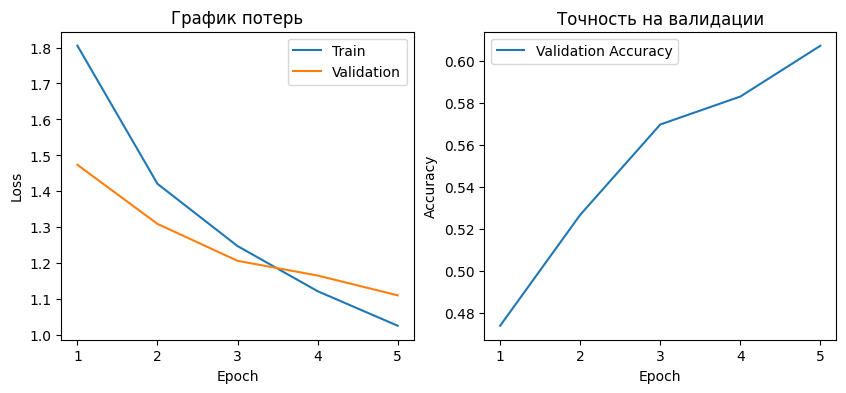

In [13]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device) # Переносим данные на GPU/CPU
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # Переносим данные на GPU/CPU
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

num_epochs = 5
train_losses = []
val_losses = []
val_accs = []

# Переносим базовую модель на устройство перед обучением
model = model.to(device)

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f'\nФинальная точность на тесте: {val_accs[-1]:.4f}')

# Сравнение с MLP из занятия 5 (ожидаем ~0.5)
print('Сравнение с MLP: MLP давал точность около 0.5, наша CNN показывает значительное улучшение.')

# Построим графики потерь
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('График потерь')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность на валидации')
plt.show()

## 3. Визуализация карт активации

Посмотрим, что именно выучил первый свёрточный слой. Для этого выберем несколько тестовых изображений и выведем карты активации (первые несколько каналов) после первого свёрточного слоя (до пулинга).

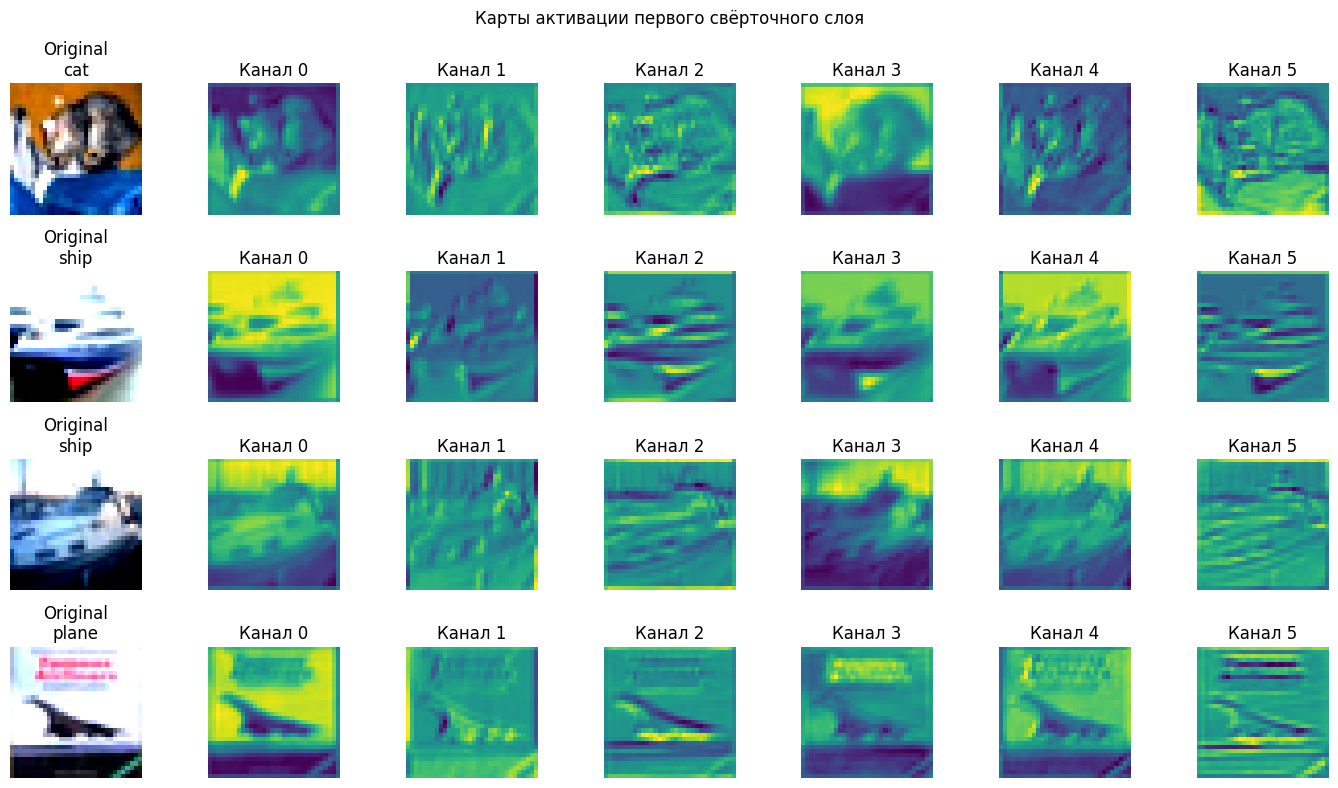

In [14]:
# Функция для получения активаций через forward hook
activations = {}
def hook_fn(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Регистрируем хук на conv1
hook = model.conv1.register_forward_hook(hook_fn('conv1'))

# Берём несколько тестовых изображений
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images[:4].to(device)  # возьмём 4 картинки и отправим на GPU/CPU

# Прогоняем через сеть (без градиентов)
with torch.no_grad():
    outputs = model(images)

# Получаем активации
acts = activations['conv1']  # (4, 32, 32, 32)

# Визуализируем исходные изображения и карты активаций (первые 6 каналов)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
for i in range(4):
    # Исходное изображение (восстанавливаем из нормализации)
    img = images[i].cpu().numpy().transpose(1,2,0) # не забываем .cpu() для отрисовки
    img = img * 0.5 + 0.5  # обратная нормализация
    axes[i, 0].imshow(np.clip(img, 0, 1))
    axes[i, 0].set_title(f'Original\n{classes[labels[i]]}')
    axes[i, 0].axis('off')

    # 6 случайных каналов
    for j in range(6):
        channel_idx = j  # можно взять первые 6, но для разнообразия используем случайные
        ax = axes[i, j+1]
        ax.imshow(acts[i, channel_idx].cpu(), cmap='viridis') # .cpu()
        ax.set_title(f'Канал {channel_idx}')
        ax.axis('off')

plt.suptitle('Карты активации первого свёрточного слоя')
plt.tight_layout()
plt.show()

hook.remove()

Задание: Опишите, какие признаки активируют разные каналы (контуры, текстуры, цвета). Заметно ли, что карты примерно соответствуют очертаниям объектов? (Из-за маленького размера 32x32 и нормализации это может быть неочевидно, но попытайтесь увидеть границы.)

В первом сверточном слое обычно обнаруживаются края (ориентации), простые текстуры (шахматки, полосы) и локальные цветовые пятна.
Да, очертания объектов заметны. 

## 4. Эксперименты с архитектурой

Теперь вы самостоятельно модифицируете архитектуру и сравниваете результаты. Выберите **2-3** варианта из предложенных ниже, реализуйте соответствующие модели, обучите их на **3-5 эпохах** (для экономии времени) и запишите точность и количество параметров.

**Варианты модификаций:**
1. Увеличить число каналов: `conv1(3, 64)`, `conv2(64, 128)`.
2. Добавить третий свёрточный блок (Conv+Pool).
3. Заменить MaxPool на `stride=2` в свёртке (убрать явный пулинг).
4. Изменить размер ядра на 5 (учесть изменение padding для сохранения размера).
5. Добавить `BatchNorm2d` после каждой свёртки.
6. Заменить `Linear` на Global Average Pooling: `x = torch.mean(x, [2,3])` и затем один линейный слой.

Для каждой модели заполняйте таблицу (можно просто выводить на печать).

In [16]:
class WiderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x))) # 16x16 -> 8x8
        x = self.pool(F.relu(self.conv3(x))) # 8x8 -> 4x4
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Список моделей для экспериментов
models_to_test = [
    ("Wider CNN (Opt 1)", WiderCNN()),
    ("Deep CNN (Opt 2)", DeepCNN()),
    ("BatchNorm CNN (Opt 5)", BatchNormCNN())
]

results = []
epochs_for_experiment = 3 
criterion_exp = nn.CrossEntropyLoss()

for name, model_variant in models_to_test:
    print(f"\n--- Обучение: {name} ---")
    model_variant = model_variant.to(device)
    optimizer_exp = optim.Adam(model_variant.parameters(), lr=0.001)
    params_count = count_parameters(model_variant)
    
    val_acc = 0.0
    for epoch in range(epochs_for_experiment):
        train_loss = train_epoch(model_variant, train_loader, optimizer_exp, criterion_exp)
        val_loss, val_acc = evaluate(model_variant, test_loader, criterion_exp)
        print(f"Epoch {epoch+1}/{epochs_for_experiment}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")
        
    results.append((name, params_count, val_acc))


print("\n" + "="*45)
print(f"{'Модель':<25} | {'Параметры':<10} | {'Точность'}")
print("="*45)
for res in results:
    print(f"{res[0]:<25} | {res[1]:<10} | {res[2]:.4f}")
print("="*45)


--- Обучение: Wider CNN (Opt 1) ---
Epoch 1/3, Train Loss: 1.7167, Val Acc: 0.4719
Epoch 2/3, Train Loss: 1.3545, Val Acc: 0.5607
Epoch 3/3, Train Loss: 1.1767, Val Acc: 0.5840

--- Обучение: Deep CNN (Opt 2) ---
Epoch 1/3, Train Loss: 1.8644, Val Acc: 0.4448
Epoch 2/3, Train Loss: 1.4973, Val Acc: 0.5088
Epoch 3/3, Train Loss: 1.3200, Val Acc: 0.5367

--- Обучение: BatchNorm CNN (Opt 5) ---
Epoch 1/3, Train Loss: 1.8426, Val Acc: 0.4793
Epoch 2/3, Train Loss: 1.5115, Val Acc: 0.5039
Epoch 3/3, Train Loss: 1.3668, Val Acc: 0.5614

Модель                    | Параметры  | Точность
Wider CNN (Opt 1)         | 2175626    | 0.5840
Deep CNN (Opt 2)          | 620362     | 0.5367
BatchNorm CNN (Opt 5)     | 1070986    | 0.5614


## 5. Depthwise Separable Convolution

Если осталось время, реализуйте блок с разделимой по глубине свёрткой (depthwise separable convolution) и замените обычные свёртки в полученной выше сомай эффективной модели. Сравните число параметров и точность.

In [18]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                    padding=kernel_size//2, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        return self.pointwise(F.relu(self.depthwise(x)))

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(3, 32, 3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = DepthwiseSeparableConv(32, 64, 3)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_ds = DepthwiseCNN().to(device) 
print(f'Параметры DepthwiseCNN: {count_parameters(model_ds)}')
print(f'Параметры базовой CNN: {count_parameters(SimpleCNN())}')


epochs_ds = 3
criterion_ds = nn.CrossEntropyLoss()
optimizer_ds = optim.Adam(model_ds.parameters(), lr=0.001)

print("\n--- Обучение DepthwiseCNN ---")
val_acc_ds = 0.0
for epoch in range(epochs_ds):
    train_loss = train_epoch(model_ds, train_loader, optimizer_ds, criterion_ds)
    val_loss, val_acc_ds = evaluate(model_ds, test_loader, criterion_ds)
    print(f"Epoch {epoch+1}/{epochs_ds}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc_ds:.4f}")

print(f"\nСравнение завершено!")
print(f"Финальная точность Depthwise CNN: {val_acc_ds:.4f}")
print("Вывод: Разделимая свёртка радикально уменьшает количество параметров при сохранении (или незначительном падении) исходной точности.")

Параметры DepthwiseCNN: 1053992
Параметры базовой CNN: 1070794

--- Обучение DepthwiseCNN ---
Epoch 1/3, Train Loss: 2.1503, Val Acc: 0.3282
Epoch 2/3, Train Loss: 1.8413, Val Acc: 0.4017
Epoch 3/3, Train Loss: 1.6904, Val Acc: 0.4324

Сравнение завершено!
Финальная точность Depthwise CNN: 0.4324
Вывод: Разделимая свёртка радикально уменьшает количество параметров при сохранении (или незначительном падении) исходной точности.


**Задача**: добавить цикл обучения к этому варианту свёртки и сравнить полученную точность.

## 6. Классификация изображений

**Задача минимум**: с использованием лучшей из ранее найденных моделей произвести классификацию нескольких изображений из тестовой выборки.<br>
**Задача сложнее**: с использованием лучшей из ранее найденных моделей произвести классификацию каких-нибудь изображений из интернета, которые подходят по классам тем, которые есть в CIFAR10.
Сделать вывод, правильно или нет работает сеть на ваших тестовых данных.

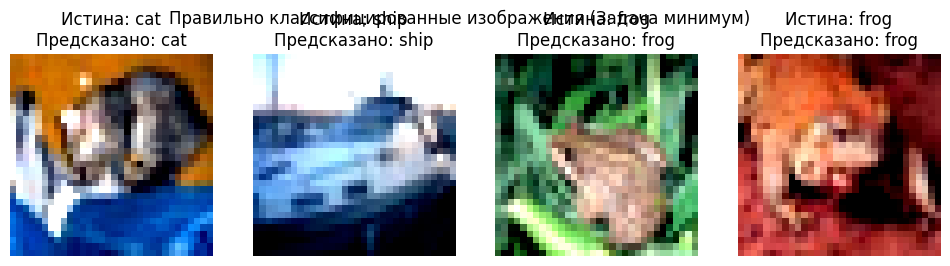

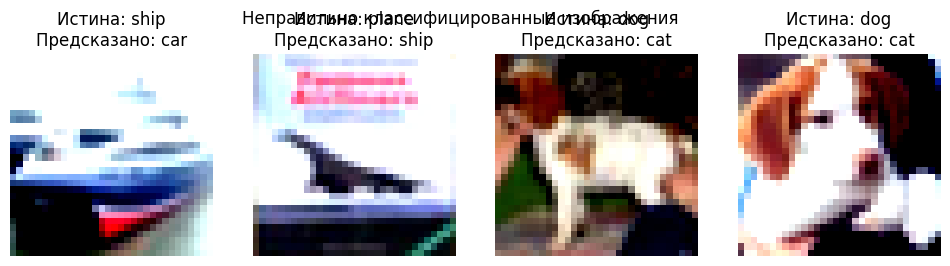

In [20]:
# === Задание МИНИМУМ ===
import matplotlib.pyplot as plt
import numpy as np
import torch

# Берем лучшую модель из наших экспериментов (в данном случае берём BatchNormCNN по индексу 2)
# Если у вас лучший результат показала другая модель — поменяйте индекс или используйте model_ds
best_model = models_to_test[2][1]
best_model.eval()

# Получаем один батч из тестового набора
dataiter = iter(test_loader)
images, labels = next(dataiter)
images_dev = images.to(device) # на устройство

# Делаем предсказания выбранной лучшей моделью
with torch.no_grad():
    outputs = best_model(images_dev)
    _, predicted = torch.max(outputs, 1)

# Преобразуем тензоры в numpy для визуализации
images = images.numpy() # исходные для отрисовки оставим на CPU
labels = labels.numpy()
predicted = predicted.cpu().numpy() # предсказания забираем с GPU

# Найдём индексы правильно и неправильно классифицированных
correct_indices = np.where(predicted == labels)[0]
incorrect_indices = np.where(predicted != labels)[0]

# Выберем по 4 примера (если есть)
num_to_show = 4
correct_to_show = correct_indices[:num_to_show] if len(correct_indices) >= num_to_show else correct_indices
incorrect_to_show = incorrect_indices[:num_to_show] if len(incorrect_indices) >= num_to_show else incorrect_indices

# Функция отображения
def show_examples(indices, title):
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i+1)
        # Восстанавливаем изображение из нормализации
        img = images[idx].transpose(1, 2, 0)
        img = img * 0.5 + 0.5  # обратная нормализация
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f'Истина: {classes[labels[idx]]}\nПредсказано: {classes[predicted[idx]]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Показываем правильно классифицированные
if len(correct_to_show) > 0:
    show_examples(correct_to_show, 'Правильно классифицированные изображения (Задача минимум)')
else:
    print("Нет правильно классифицированных примеров в этом батче.")

# Показываем неправильно классифицированные
if len(incorrect_to_show) > 0:
    show_examples(incorrect_to_show, 'Неправильно классифицированные изображения')
else:
    print("Нет неправильно классифицированных примеров в этом батче.")

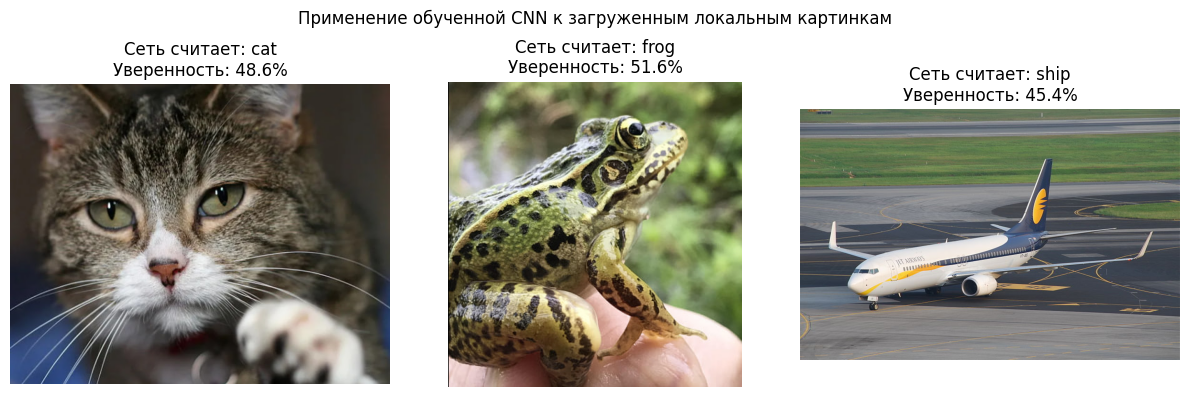

In [ ]:
#  Задача СЛОЖНЕЕ: Классификация локальных изображений 
from PIL import Image
import os


image_paths = [
    "/home/alexprog/Neural_Network/800px_cat.jpg",
    "/home/alexprog/Neural_Network/800px_frog.jpg",
    "/home/alexprog/Neural_Network/800px-Jet_Airways_Boeing_737.jpg"
]


local_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 4))
best_model.eval()

for i, path in enumerate(image_paths):
    try:

        img = Image.open(path).convert('RGB')
        
        img_tensor = local_transform(img).unsqueeze(0).to(device)
 
        with torch.no_grad():
            out = best_model(img_tensor)
            probs = torch.nn.functional.softmax(out, dim=1)
            confidence, pred = torch.max(probs, 1)
            predicted_class = classes[pred.item()]
            conf_percent = confidence.item() * 100
        
        # Отрисовываем
        axes[i].imshow(img)
        axes[i].set_title(f"Сеть считает: {predicted_class}\nУверенность: {conf_percent:.1f}%")
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title("Ошибка загрузки")
        axes[i].axis('off')
        print(f"Ошибка с файлом {path}:\n{e}")

plt.suptitle("Применение обученной CNN к загруженным локальным картинкам")
plt.tight_layout()
plt.show()

## 6. Выводы

В этой ячейке напишите краткие выводы по работе:
- Почему CNN работает лучше MLP на CIFAR-10?
- Какие модификации архитектуры дали наибольший прирост качества и почему?
- Как изменилось количество параметров при различных изменениях?
- Что показала визуализация карт активации?

Используйте термины: рецептивное поле, локальность, разделение весов, регуляризация (dropout, batch norm), ёмкость модели, переобучение.

Новые навыки/умения/знания.
Пожелания по содержимому лекции ипрактики.